In [5]:
import pandas as pd # importando biblioteca essencial

In [6]:
df = pd.read_excel('../data/data.xlsx') # lendo o arquivo excel e armazenando em um DataFrame

In [7]:
df.info() # exibindo informações sobre o DataFrame, como número de linhas, colunas e tipos de dados

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 20 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Município de vacinação                              444 non-null    str    
 1   Idade Evento                                        444 non-null    float64
 2   Data da Notificação                                 444 non-null    object 
 3   Raça/Cor                                            444 non-null    object 
 4   Sexo                                                444 non-null    str    
 5   Imunobiológico (vacina)                             444 non-null    str    
 6   Dose                                                443 non-null    str    
 7   Gestante                                            444 non-null    object 
 8   Mês de gestação                                     444 non-null    float64
 9   Mulher ama

# Tratamento da coluna data

A coluna data não segue uma padronização clara. Enquanto algumas linhas apresentam apenas a informação do ano, outras apresentam a data completa.

É necessário tratar e padronizar a coluna de data.

In [8]:
# Convertendo a coluna 'Data da Notificação' para string e removendo espaços em branco
df['Data da Notificação'] = df['Data da Notificação'].astype(str).str.strip()

In [9]:
# Extraindo o ano da notificação e criando uma nova coluna 'Ano_Notificacao'
df['Ano_Notificacao'] = df['Data da Notificação'].str[:4]

In [10]:
# Convertendo de volta para o formato correto
df['Data_Completa_Notificacao'] = pd.to_datetime(df['Data da Notificação'], errors='coerce')

## Função de limpeza auxiliar

In [11]:
# Função para remover espaços, caracteres ocultos e padronizar maiúsculas
def limpar_e_padronizar_texto(texto):
    if pd.isna(texto):
        return None
    
    # Transforma em string e remove espaços normais nas pontas
    texto_str = str(texto).strip()
    
    # Remove quebras de linha e tabulações ocultas do Excel
    texto_str = pd.Series(texto_str).str.replace(r'[\r\n\t]+', '', regex=True).iloc[0]
    
    # Remove espaços duplos ou triplos no meio do texto
    texto_str = pd.Series(texto_str).str.replace(r'\s+', ' ', regex=True).iloc[0]
    
    # Força apenas a primeira letra em maiúscula para análise de termos
    texto_str = texto_str.capitalize()
    texto_lower = texto_str.lower()
    
    # Unifica todas as variações de Pfizer Pediátrica
    if 'pediat' in texto_lower or 'pediát' in texto_lower:
        if 'pfiz' in texto_lower or 'pfie' in texto_lower or 'pfzi' in texto_lower:
            return 'Pfizer pediátrica'
            
    # Unifica os erros de digitação da Pfizer convencional
    if 'pfiz' in texto_lower or 'pfzi' in texto_lower or 'pfier' in texto_lower:
        if 'pediat' not in texto_lower and 'pediát' not in texto_lower and 'bival' not in texto_lower:
            return 'Pfizer'
            
    # Unifica os erros de digitação da Janssen
    if 'jans' in texto_lower or 'jass' in texto_lower:
        return 'Janssen'
        
    # Unifica cefaleia com ou sem acento e dor de cabeça
    if 'cefal' in texto_lower or 'dor de cabeç' in texto_lower:
        return 'Cefaleia'
        
    # Unifica mialgia e dor muscular
    if 'mialg' in texto_lower or 'dor muscul' in texto_lower:
        return 'Mialgia'
        
    # Unifica pirexia e febre
    if 'febre' in texto_lower or 'pirex' in texto_lower:
        return 'Febre'
        
    # Unifica fraqueza e astenia
    if 'fraqueza' in texto_lower or 'asten' in texto_lower:
        return 'Fraqueza'
        
    # Unifica as variações de náusea com ou sem acento
    if 'naus' in texto_lower or 'náus' in texto_lower:
        return 'Náusea'
    
    # Retorna None caso o resultado tenha ficado vazio
    if texto_str in ['Nan', 'None', '0', '']:
        return None
        
    return texto_str

# Tratando múltiplas informações nas colunas vacina e dose

As colunas vacina e dose apresentam mais de uma informação por entrada.
É de extrema importância dividir esses informações em colunas adjacentes, visando facilitar a busca, leitura e processamento dos dados nessas colunas.

In [12]:
# separando as vacinas pelo separador / e criando novas colunas para cada vacina
vacinas_separadas = df['Imunobiológico (vacina)'].str.split('/', expand=True).add_prefix('Vacina_')

In [13]:
# separando as doses pelo separador / e criando novas colunas para cada dose
doses_separadas = df['Dose'].str.split('/', expand=True).add_prefix('Dose_')

In [14]:
for col in vacinas_separadas.columns:
    vacinas_separadas[col] = vacinas_separadas[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    vacinas_separadas[col] = vacinas_separadas[col].apply(limpar_e_padronizar_texto)

for col in doses_separadas.columns:
    doses_separadas[col] = doses_separadas[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    doses_separadas[col] = doses_separadas[col].apply(limpar_e_padronizar_texto)

In [15]:
df = pd.concat([df, vacinas_separadas, doses_separadas], axis=1) # juntando as novas colunas de vacinas e doses ao DataFrame original

# Limpeza e Padronização dos Eventos e Desfechos

Vamos aplicar uma limpeza em lote nessas colunas de uma vez só, usando expressões regulares (regex) para remover os prefixos numéricos e os espaços em branco que sobram nas pontas.

In [16]:
colunas_para_limpar = [
    'Tipo de Evento', 
    'Reação / evento adverso', 
    'Classificação de gravidade', 
    'Desfecho (evolução do caso)'
]

# Limpeza padrão
for col in colunas_para_limpar:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(r'^\d+:\s*', '', regex=True)
    df[col] = df[col].str.strip()
    df[col] = df[col].replace(['nan', 'NaN', '0', ''], None)

# Separar as colunas por barra '/'
eventos_separados = df['Tipo de Evento'].str.split('/', expand=True).add_prefix('Evento_')

for col in eventos_separados.columns:
    # Remove o padrão de numeração inicial e aplica a função de padronização completa
    eventos_separados[col] = eventos_separados[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    eventos_separados[col] = eventos_separados[col].apply(limpar_e_padronizar_texto)
    
    # Cria uma variável temporária em minúsculo para busca de termos específicos
    texto_lower = eventos_separados[col].astype(str).str.lower()
    
    # Substitui os textos com base nos termos encontrados independente da digitação original
    eventos_separados.loc[texto_lower.str.contains('erro') & texto_lower.str.contains('imuniza'), col] = 'Erro de Imunização'
    eventos_separados.loc[texto_lower.str.contains('evento') | texto_lower.str.contains('reaç') | texto_lower.str.contains('adverso'), col] = 'Evento Adverso'
    
    # Garante que textos vazios virem None de verdade
    eventos_separados[col] = eventos_separados[col].replace(['None', 'Nan', ''], None)

# Junta de volta no DataFrame principal
df = pd.concat([df, eventos_separados], axis=1)

# 5. Remove a coluna velha
df = df.drop(columns=['Tipo de Evento'], errors='ignore')

# Tratando coluna gravidade

In [17]:
# Separar e criar as colunas de classificação de gravidade múltiplas
gravidade_separada = df['Classificação de gravidade'].str.split('/', expand=True).add_prefix('Gravidade_')

for col in gravidade_separada.columns:
    # Remove o padrão de numeração inicial e aplica a função de padronização completa
    gravidade_separada[col] = gravidade_separada[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    gravidade_separada[col] = gravidade_separada[col].apply(limpar_e_padronizar_texto)
    gravidade_separada[col] = gravidade_separada[col].replace(['None', 'Nan', ''], None)

# Separar e criar as colunas de desfecho múltiplas
desfecho_separado = df['Desfecho (evolução do caso)'].str.split('/', expand=True).add_prefix('Desfecho_')

for col in desfecho_separado.columns:
    # Remove o padrão de numeração inicial e aplica a função de padronização completa
    desfecho_separado[col] = desfecho_separado[col].astype(str).str.replace(r'^\d+:\s*', '', regex=True)
    desfecho_separado[col] = desfecho_separado[col].apply(limpar_e_padronizar_texto)
    desfecho_separado[col] = desfecho_separado[col].replace(['None', 'Nan', ''], None)

# Cria uma lista com todas as colunas de gravidade geradas pelo split
colunas_gravidade = [col for col in gravidade_separada.columns]

# Função para encontrar a maior gravidade na linha do paciente
def definir_maior_gravidade(linha):
    valores = set(linha.dropna().astype(str))
    if 'Grave' in valores:
        return 'Grave'
    if 'Não grave' in valores:
        return 'Não grave'
    return None

# Aplica a busca da maior gravidade por linha
df['Gravidade_Final'] = gravidade_separada[colunas_gravidade].apply(definir_maior_gravidade, axis=1)

# Junta as novas colunas de gravidade e desfecho ao DataFrame original
df = pd.concat([df, gravidade_separada, desfecho_separado], axis=1)

# Remove as colunas antigas que foram divididas para manter a base limpa
df = df.drop(columns=['Classificação de gravidade', 'Desfecho (evolução do caso)'], errors='ignore')

## Tratamento coluna reações

In [18]:
# Separar e criar as colunas de reações múltiplas com base no divisor barra
reacoes_separadas = df['Reação / evento adverso'].str.split('/', expand=True).add_prefix('Reacao_')

# Passamos por cada nova coluna gerada para limpar os números e padronizar o texto
for col in reacoes_separadas.columns:
    # Garante que a coluna seja interpretada como texto antes do Regex
    reacoes_separadas[col] = reacoes_separadas[col].astype(str)
    
    # Remove o padrão de numeração inicial (ex: "1: ", "2: ") que o sistema adiciona
    reacoes_separadas[col] = reacoes_separadas[col].str.replace(r'^\d+:\s*', '', regex=True)
    
    # Remove espaços em branco que sobram nas pontas após retirar os números
    reacoes_separadas[col] = reacoes_separadas[col].str.strip()
    
    # Aplica a função de limpeza genérica para unificar a grafia e maiúsculas
    reacoes_separadas[col] = reacoes_separadas[col].apply(limpar_e_padronizar_texto)
    
    # Garante que textos nulos ou vazios fiquem como None padrão do Python
    reacoes_separadas[col] = reacoes_separadas[col].replace(['None', 'Nan', ''], None)

# Junta as colunas de reações tratadas de volta ao DataFrame principal
df = pd.concat([df, reacoes_separadas], axis=1)

# Remove a coluna velha original para manter a base limpa e organizada
df = df.drop(columns=['Reação / evento adverso'], errors='ignore')

# Tratando colunas medicamentos e doenças

Muitas linhas nessas colunas vem com valor 0 ou 'Não' para indicar que a pessoa não tinha doenças ou usava medicamentos.
Devemos padronizar uma forma comum de sinalizar o que é "Sem informação".

In [19]:
colunas_finais = [
    'Doenças (CID10) - Preexistente', 
    'Medicamento em uso anterior ou durante a vacinação', 
    'Nome do Medicamento'
]

for col in colunas_finais:
    # Garantir que tudo seja texto e remover espaços extras nas pontas
    df[col] = df[col].astype(str).str.strip()
    
    # Remover prefixos numéricos 
    df[col] = df[col].str.replace(r'^\d+:\s*', '', regex=True)
    
    # Padronizar respostas negativas ou vazias para facilitar filtros futuros.
    
    valores_vazios = ['0', 'Não', 'Não ', 'nan', 'NaN', '-', '']
    df[col] = df[col].replace(valores_vazios, 'Não se aplica / Nenhum')

# Remoção de colunas duplicadas(geradas durante o tratamento)

In [20]:
colunas_para_remover = [
    'Data da Notificação',   
    'Imunobiológico (vacina)',  
    'Dose'
]

# O método .drop remove as colunas. 
# O errors='ignore' serve para o código não quebrar caso você rode o script de novo e a coluna já não exista.
df = df.drop(columns=colunas_para_remover, errors='ignore')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   Município de vacinação                              444 non-null    str           
 1   Idade Evento                                        444 non-null    float64       
 2   Raça/Cor                                            444 non-null    object        
 3   Sexo                                                444 non-null    str           
 4   Gestante                                            444 non-null    object        
 5   Mês de gestação                                     444 non-null    float64       
 6   Mulher amamentando no momento da vacinação?         444 non-null    str           
 7   Gravidade                                           444 non-null    object        
 8   Doenças (CID10) - Pre

# Salvando localmente

Trecho simples para salvamendo local do novo DataFrame em um xlsx.

In [22]:
nome_do_arquivo = '../data/dados_tratados.xlsx'

df.to_excel(nome_do_arquivo, index=False)

# Gerando gráficos

In [23]:
import plotly.express as px # importando biblioteca para visualização de dados
import plotly.io as pio # importando módulo para configurar renderização de gráficos

pio.renderers.default = 'png' # renderizar como PNG. Substitua por 'nobebook' se quiser visualizar interativamente no Jupyter Notebook

## Distribuição evento X idade

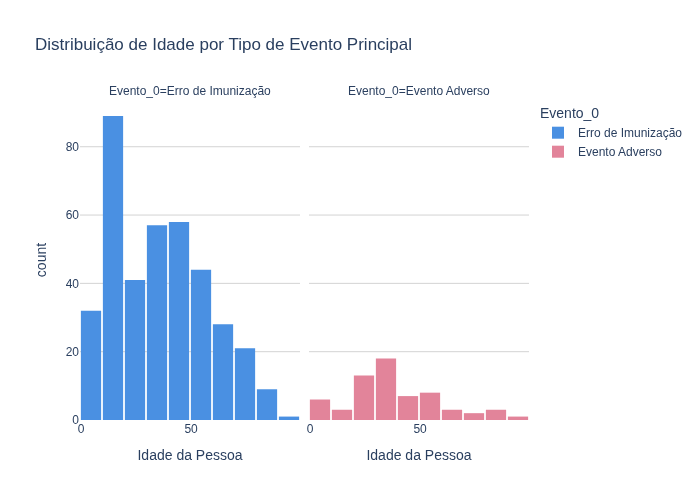

In [24]:
# Removemos apenas quem não tem idade ou evento principal preenchido

df_grafico = df.dropna(subset=['Idade Evento', 'Evento_0']).copy()

# Garante que a idade seja numérica
df_grafico['Idade Evento'] = pd.to_numeric(df_grafico['Idade Evento'], errors='coerce')
df_grafico = df_grafico.dropna(subset=['Idade Evento'])

# Criamos o Histograma dividido por colunas
fig_distribuicao = px.histogram(
    df_grafico, 
    x='Idade Evento', 
    facet_col='Evento_0',       # Cria um gráfico lado a lado para cada tipo de evento
    color='Evento_0',          
    nbins=12,  
    title='Distribuição de Idade por Tipo de Evento Principal',
    labels={'Idade Evento': 'Idade da Pessoa', 'count': 'Casos'},
    color_discrete_sequence=['#4A90E2', '#E2849A', '#A0D468'] # Cores limpas
)

# Ajustes visuais para garantir que fique idêntico a um relatório
fig_distribuicao.update_layout(
    plot_bgcolor='white',      
    font=dict(size=12),          
    bargap=0.08                  
)

# Adiciona linhas de grade horizontais e garante eixos independentes se necessário
fig_distribuicao.update_yaxes(showgrid=True, gridcolor='LightGrey')

fig_distribuicao.show()

## Proporção de erros X Tipo de Vacina

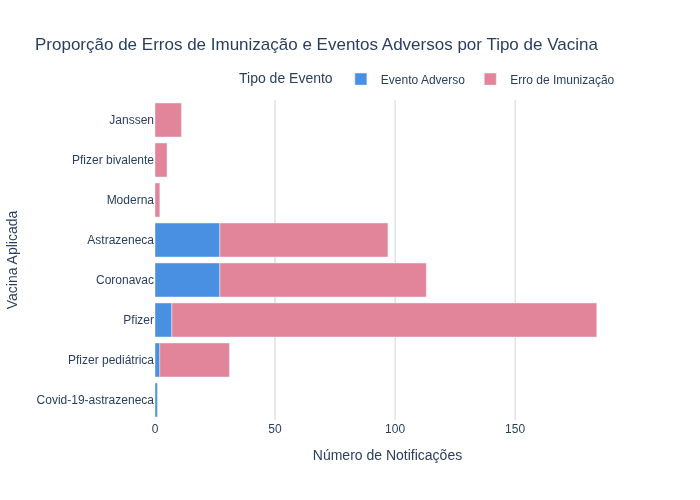

In [25]:
# Removemos quem não tem a vacina principal ou o evento principal preenchidos
df_vacinas = df.dropna(subset=['Vacina_0', 'Evento_0']).copy()

# Agrupamos os dados para contar a quantidade de casos por vacina e evento
df_contagem = df_vacinas.groupby(['Vacina_0', 'Evento_0']).size().reset_index(name='Quantidade')

# Ordenamos para que as vacinas com mais notificações fiquem no topo
df_contagem = df_contagem.sort_values(by='Quantidade', ascending=True)

# Criamos o gráfico de barras horizontais dividido por cores
fig_vacinas = px.bar(
    df_contagem,
    y='Vacina_0',
    x='Quantidade',
    color='Evento_0',
    orientation='h',
    title='Proporção de Erros de Imunização e Eventos Adversos por Tipo de Vacina',
    labels={'Vacina_0': 'Vacina Aplicada', 'Quantidade': 'Número de Notificações', 'Evento_0': 'Tipo de Evento'},
    color_discrete_sequence=['#4A90E2', '#E2849A']
)

# Ajustes visuais para garantir que fique idêntico a um relatório
fig_vacinas.update_layout(
    plot_bgcolor='white',
    font=dict(size=12),
    bargap=0.15,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Adiciona linhas de grade horizontais e garante eixos independentes se necessário
fig_vacinas.update_xaxes(showgrid=True, gridcolor='LightGrey')

fig_vacinas.show()

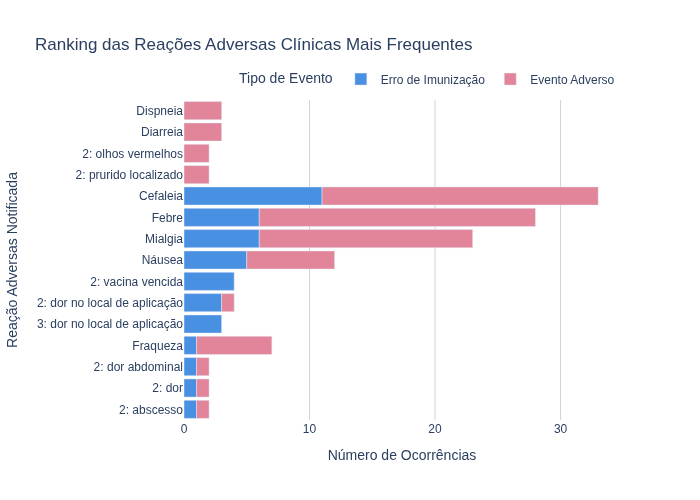

In [26]:
# Identifica automaticamente todas as novas colunas de reações que foram geradas pelo split
colunas_reacao = [col for col in df.columns if col.startswith('Reacao_')]

# Transforma as colunas em linhas usando o melt para podermos contabilizar todas de uma vez só
df_reacoes_longo = df.melt(id_vars=['Evento_0'], value_vars=colunas_reacao, value_name='Reacao')
df_reacoes_longo = df_reacoes_longo.dropna(subset=['Reacao'])

# Filtramos termos que indicam erro de administração e que não são sintomas clínicos reais
termos_para_remover = [
    'Vacina vencida', 'Dose inadequada', 'Vacina incorreta', 
    'Vacina para idade inadequada', 'Dose subterapêutica de vacina',
    'Intervalo de administração de dose do medicamento muito curto',
    'Administração de vacina para idade inadequada'
]
df_reacoes_longo = df_reacoes_longo[~df_reacoes_longo['Reacao'].isin(termos_para_remover)]

# Agrupamos os dados para contar a frequência real de cada sintoma clínico
df_contagem_reacao = df_reacoes_longo.groupby(['Reacao', 'Evento_0']).size().reset_index(name='Quantidade')

# Limitamos o gráfico às 15 reações mais frequentes para evitar poluição visual no relatório
top_reacoes = df_contagem_reacao.groupby('Reacao')['Quantidade'].sum().nlargest(15).index
df_contagem_reacao = df_contagem_reacao[df_contagem_reacao['Reacao'].isin(top_reacoes)]

# Ordenamos para que o sintoma mais recorrente apareça no topo
df_contagem_reacao = df_contagem_reacao.sort_values(by='Quantidade', ascending=True)

# Criamos o gráfico de barras horizontais para o ranking de reações
fig_reacoes = px.bar(
    df_contagem_reacao,
    y='Reacao',
    x='Quantidade',
    color='Evento_0',
    orientation='h',
    title='Ranking das Reações Adversas Clínicas Mais Frequentes',
    labels={'Reacao': 'Reação Adversas Notificada', 'Quantidade': 'Número de Ocorrências', 'Evento_0': 'Tipo de Evento'},
    color_discrete_sequence=['#4A90E2', '#E2849A']
)

# Ajustes visuais para garantir que fique idêntico a um relatório
fig_reacoes.update_layout(
    plot_bgcolor='white',
    font=dict(size=12),
    bargap=0.15,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Adiciona linhas de grade horizontais e garante eixos independentes se necessário
fig_reacoes.update_xaxes(showgrid=True, gridcolor='LightGrey')

fig_reacoes.show()

# Tratamentos para correlação

## Gerando dados quantitativos

In [ ]:
df_matriz = pd.DataFrame()

# Variáveis Numéricas Diretas
df_matriz["Idade"] = df["Idade Evento"]
df_matriz["Mes_Gestacao"] = df["Mês de gestação"].fillna(0)

df_matriz["Sexo_Feminino"] = df["Sexo"].apply(
    lambda x: 1 if str(x).strip().upper() in ["F", "FEMININO"] else 0
)

df_matriz["Teve_Atendimento"] = df["Houve atendimento médico?"].apply(
    lambda x: 1 if str(x).strip().upper() in ["SIM", "S"] else 0
)

df_matriz["É_Gestante"] = df["Gestante"].apply(
    lambda x: 1 if str(x).strip().upper() in ["SIM", "S"] else 0
)

colunas_vacina = [c for c in df.columns if c.startswith("Vacina_")]
df_matriz["Qtd_Vacinas"] = df[colunas_vacina].notna().sum(axis=1)

colunas_dose = [c for c in df.columns if c.startswith("Dose_")]
df_matriz["Qtd_Doses"] = df[colunas_dose].notna().sum(axis=1)

colunas_reacao = [c for c in df.columns if c.startswith("Reacao_")]
df_matriz["Qtd_Reacoes"] = df[colunas_reacao].notna().sum(axis=1)


df_matriz["Caso_Grave"] = df["Gravidade_Final"].apply(
    lambda x: 1 if str(x).strip().lower() in ["grave", "sim", "s"] else 0
)

df_matriz = df_matriz.dropna(subset=["Idade"])

## Visualização do heatmap

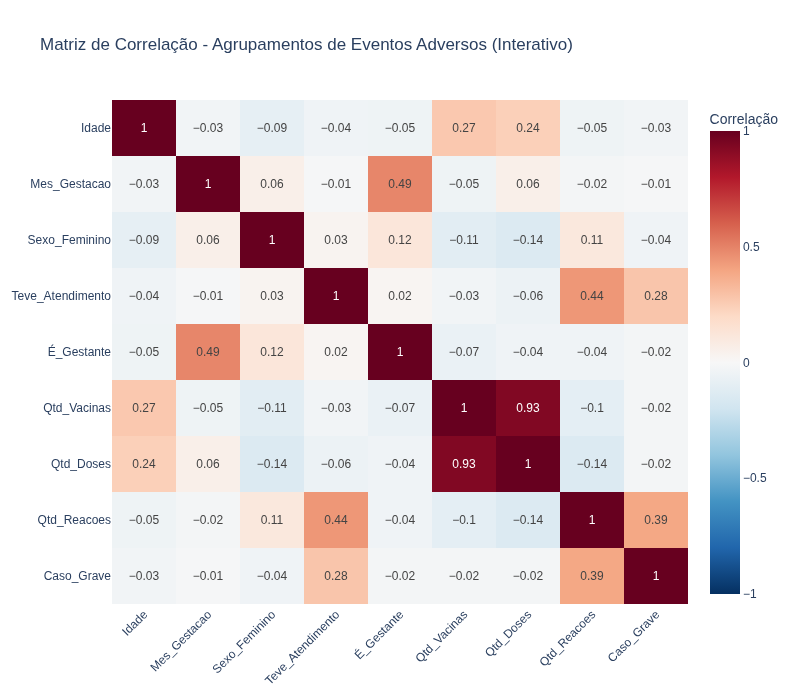

In [ ]:
matriz_correlacao = df_matriz.corr(method="pearson")


matriz_correlacao = df_matriz.corr(method="pearson")

matriz_arredondada = matriz_correlacao.round(2)

fig = px.imshow(
    matriz_arredondada,
    text_auto=True,  # Exibe os números dentro dos quadrados automaticamente
    aspect="auto",  # Ajusta o tamanho das células automaticamente
    color_continuous_scale="RdBu_r",  # Escala clássica (Vermelho positivo, Azul negativo)
    labels=dict(color="Correlação"),  # Legenda da barra de cores
    x=matriz_arredondada.columns,
    y=matriz_arredondada.index,
    title="Matriz de Correlação - Agrupamentos de Eventos Adversos (Interativo)",
    range_color=[-1, 1], 
)

fig.update_layout(
    width=800,
    height=700,
    xaxis_tickangle=-45,  
    coloraxis_colorbar=dict(
        tickvals=[-1, -0.5, 0, 0.5, 1],  
    ),
)

fig.show()

#### Qtde_reacoes vs Teve_atendimento

Qtd_Reacoes vs Teve_Atendimento (0.44): É uma correlação positiva moderada. Mostra que o volume de sintomas que o paciente manifesta simultaneamente é um fator crucial para que ele busque ou precise de atendimento médico.

#### Qtd_Reacoes vs Caso_Grave

Qtd_Reacoes vs Caso_Grave (0.39): Uma correlação positiva moderada. O acúmulo de reações/sintomas diferentes em um mesmo paciente caminha junto com a classificação do caso como "Grave".

#### Teve_Atendimento vs Caso_Grave

Teve_Atendimento vs Caso_Grave (0.28): Correlação positiva de fraca a moderada. Indica que casos graves tendem a passar por atendimento médico, mas não de forma absoluta.

## Scatter matrix

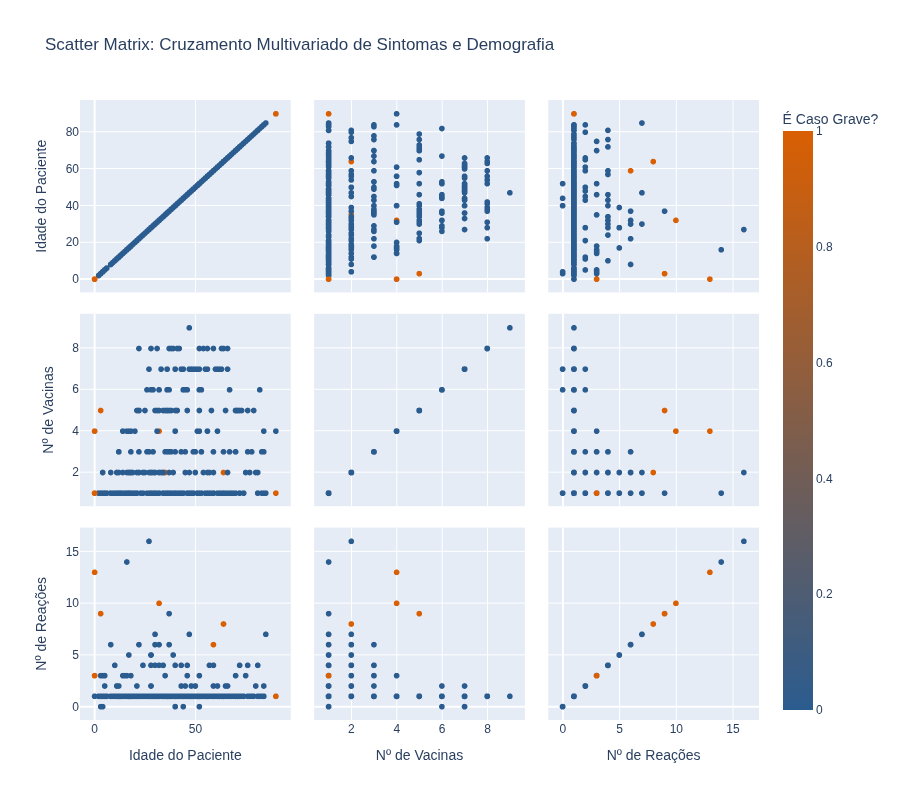

In [ ]:
fig_matrix = px.scatter_matrix(
    df_matriz,
    dimensions=["Idade", "Qtd_Vacinas", "Qtd_Reacoes"],
    color="Caso_Grave", 
    color_continuous_scale=["#2b5c8f", "#d95f02"], 
    title="Scatter Matrix: Cruzamento Multivariado de Sintomas e Demografia",
    labels={
        "Idade": "Idade do Paciente",
        "Qtd_Vacinas": "Nº de Vacinas",
        "Qtd_Reacoes": "Nº de Reações",
        "Caso_Grave": "É Caso Grave?",
    },
)

fig_matrix.update_layout(
    width=900,
    height=800,
    dragmode="select", 
)

fig_matrix.show()

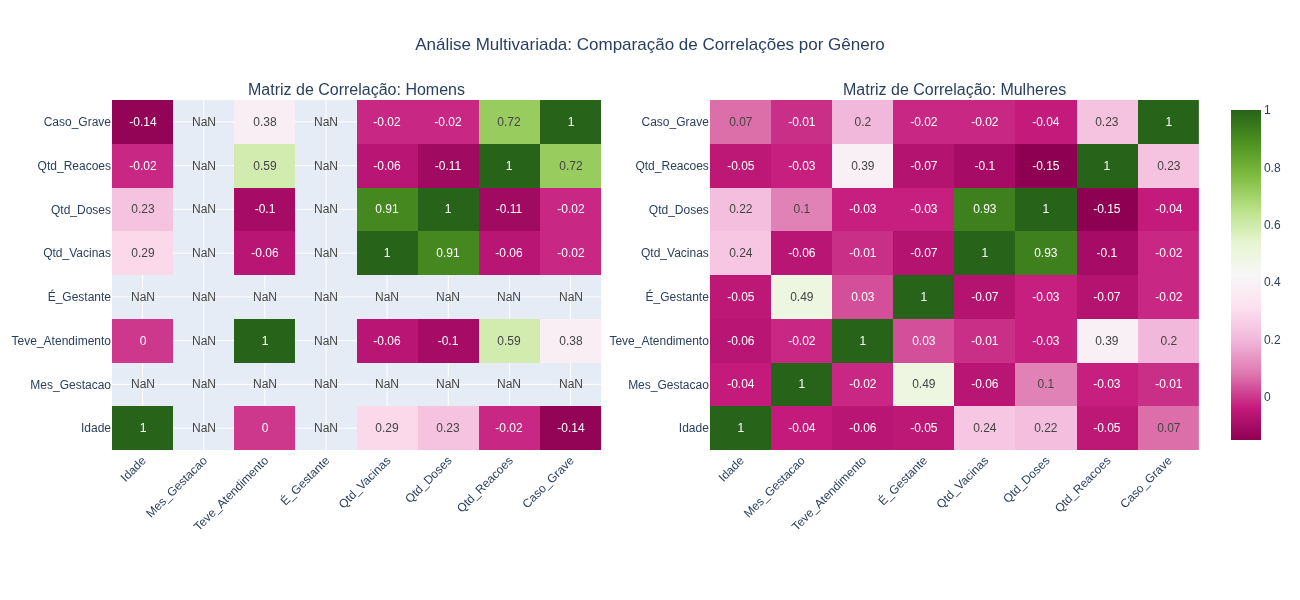

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_masc = df_matriz[df_matriz["Sexo_Feminino"] == 0].drop(
    columns=["Sexo_Feminino", "Sexo_Label", "Status_Caso", "Gravidade_Label"],
    errors="ignore",
)
df_fem = df_matriz[df_matriz["Sexo_Feminino"] == 1].drop(
    columns=["Sexo_Feminino", "Sexo_Label", "Status_Caso", "Gravidade_Label"],
    errors="ignore",
)

corr_masc = df_masc.corr(method="pearson").round(2)
corr_fem = df_fem.corr(method="pearson").round(2)

fig_co_facet = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Matriz de Correlação: Homens",
        "Matriz de Correlação: Mulheres",
    ),
)

fig_co_facet.add_trace(
    go.Heatmap(
        z=corr_masc.values,
        x=corr_masc.columns,
        y=corr_masc.index,
        coloraxis="coloraxis",
        text=corr_masc.values,
        texttemplate="%{text}", 
    ),
    row=1,
    col=1,
)

fig_co_facet.add_trace(
    go.Heatmap(
        z=corr_fem.values,
        x=corr_fem.columns,
        y=corr_fem.index,
        coloraxis="coloraxis",
        text=corr_fem.values,
        texttemplate="%{text}",
    ),
    row=1,
    col=2,
)

fig_co_facet.update_layout(
    title_text="Análise Multivariada: Comparação de Correlações por Gênero",
    title_x=0.5,  
    width=1300,  
    height=600,  
    margin=dict(
        l=100, r=100, t=100, b=150
    ),  
)

fig_co_facet.update_xaxes(
    tickangle=-45, row=1, col=1
) 
fig_co_facet.update_xaxes(
    tickangle=-45, row=1, col=2
) 


fig_co_facet.show()